In [ ]:
%load_ext autoreload
%autoreload 2
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from data_preparation import create_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images/255.0
train_images = np.expand_dims(train_images, axis=-1)

In [25]:
(image_pairs, labels) = create_data(train_images, train_labels)


In [26]:
labels

array([1, 0, 1, ..., 0, 1, 0])

In [27]:
perm = np.random.permutation(len(image_pairs))
image_pairs = image_pairs[perm]
labels = labels[perm]

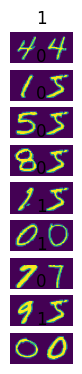

In [28]:
for i in range(1, 10):
    imageA = image_pairs[i-1][0]
    imageB = image_pairs[i-1][1]
    image = np.hstack([imageA, imageB])
    ax = plt.subplot(10, 1, i)
    plt.imshow(image)
    plt.title(labels[i-1])
    ax.axis('off')

plt.show()

In [16]:
labels[1:10]

array([[1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1]])

In [29]:
import tensorflow as tf

def contrastive_loss(y_true, y_pred, margin=1.0):
    y_true = tf.cast(y_true, y_pred.dtype)
    square_pred = tf.math.square(y_pred)
    margin_square = tf.math.square(tf.math.maximum(margin - y_pred, 0))
    return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)

In [ ]:
from model import create_siamese_network
from tensorflow.keras.optimizers import Adam

adam = Adam(0.01)

model = create_siamese_network((28, 28, 1))
model.compile(optimizer=adam, loss='binary_crossentropy', metrics=['accuracy'])
model.fit([image_pairs[:, 0], image_pairs[:, 1]], labels[:], epochs=10, batch_size=128, validation_split=0.1)

Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.5019 - loss: 0.9086 - val_accuracy: 0.5085 - val_loss: 0.8457
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.5269 - loss: 0.6974 - val_accuracy: 0.5610 - val_loss: 0.7241
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - accuracy: 0.5731 - loss: 0.6748 - val_accuracy: 0.5860 - val_loss: 0.6825


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
2 0 [[0.36133134]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2 4 [[0.5707207]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2 1 [[0.2507791]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2 9 [[0.44062817]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2 2 [[0.35551935]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2 1 [[0.5173142]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2 3 [[0.26439625]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
2 1 [[0.5489011]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2 4 [[0.5994997]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2 3 [[0.4077648]]


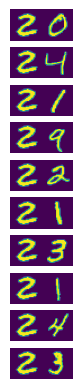

In [39]:

image = np.expand_dims(train_images[25], 0)
image_label = train_labels[25]

for i in range(1, 11):
    
    image_a = np.expand_dims(train_images[i], axis=0)
    label_a = train_labels[i]
    predictions = model.predict([image, image_a])
    print(f'{image_label} {label_a} {predictions}')
    
    s = np.hstack([np.reshape(image, (28, 28)), np.reshape(image_a, (28, 28))])
    plt.subplot(10, 1, i)
    plt.axis('off')
    plt.imshow(s)

plt.show()

    
